# Otonom Drone Görüntüleri ile Nesne Tespiti (YOLOv8)

## 1. Proje Tanımı ve Eğitim Hazırlığı
Bu çalışmanın amacı, otonom İHA (Drone) sistemleri için kritik olan nesne tespiti görevini gerçekleştirmektir. Drone kamerasından alınan görüntüler üzerindeki belirli geometrik şekillerin (**Mavi Altıgen, Mavi Kare, Kırmızı Üçgen, Kırmızı Kare**) tespit edilmesi hedeflenmiştir.

### 1.1. Veri Seti Yapısı
Çalışmada kullanılan veri seti, **YOLO formatında** etiketlenmiştir.
* **Eğitim (Train):** Modelin öğrenmesi için kullanılan ana veri grubu.
* **Doğrulama (Validation):** Her epoch sonunda modelin başarısını ölçmek için kullanılan veri grubu.
* **Test:** Modelin eğitim bittikten sonra "gerçek hayat" performansını ölçmek için ayrılan veri grubu.

### 1.2. Eğitim Konfigürasyonu
Eğitim sürecinde **Ultralytics YOLOv8n (Nano)** modeli tercih edilmiştir.
* **Transfer Learning:** Model, COCO ağırlıkları (`yolov8n.pt`) ile başlatılarak bu şekiller için özelleştirilmiştir.
* **Epochs:** 20 (Modelin veri setini turlama sayısı).
* **Image Size:** 640x640 piksel. (standart)

## Modelin Eğitimi

In [2]:
from ultralytics import YOLO
import os

# 1. (Nano model hızlıdır, small biraz daha zekidir. Şimdilik 'n' ile başlayalım)
model = YOLO('yolov8n.pt')  

yaml_path = os.path.abspath("yoda_odevlendirme_veriseti.yolov8/data.yaml")

print(f"Eğitim şu dosya ile başlayacak: {yaml_path}")

# 3. Eğitimi Başlat
# epochs=20: Deneme amaçlı 20 tur yeterli, süreye göre arttırılabilir.
# imgsz=640: Standart boyut.
results = model.train(
    data=yaml_path, 
    epochs=20, 
    imgsz=640, 
    name='yoda_modeli'
)

Eğitim şu dosya ile başlayacak: c:\Users\aydin\Desktop\Yazılım\Git\Aydin_Alizade_YODA_IHA_YAZILIM\Odev_5\yoda_odevlendirme_veriseti.yolov8\data.yaml
Ultralytics 8.3.241  Python-3.11.9 torch-2.9.1+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\aydin\Desktop\Yazlm\Git\Aydin_Alizade_YODA_IHA_YAZILIM\Odev_5\yoda_odevlendirme_veriseti.yolov8\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

## Performans Analizi ve Metrikler
Modelin 20 epoch süren eğitimi tamamlanmış ve elde edilen sonuçlar analiz edilmiştir. Aşağıdaki grafikler modelin başarısını özetlemektedir:

### Metriklerin Anlamları
1.  **Karmaşıklık Matrisi (Confusion Matrix):** Modelin tahminleri ile gerçek sınıflar arasındaki ilişkiyi gösterir. Matrisin köşegeni üzerindeki koyu renkli alanlar, modelin sınıfları birbirine karıştırmadan doğru tespit ettiğini kanıtlar.
2.  **Eğitim Grafikleri (Results):**
    * **Box Loss:** Kutucuk hatasının eğitim boyunca düşmesi, modelin nesne konumlarını daha hassas bulduğunu gösterir.
    * **mAP (Mean Average Precision):** Modelin genel başarı puanıdır. %95 üzerindeki değerler modelin yüksek performans gösterdiğini ifade eder.
3.  **Precision-Recall Eğrisi:** Eğrinin sağ üst köşeye (1.0) yakın olması, modelin hem yanlış alarm vermediğini (Precision) hem de nesneleri gözden kaçırmadığını (Recall) gösterir.

=== Karmaşıklık Matrisi (Confusion Matrix) ===


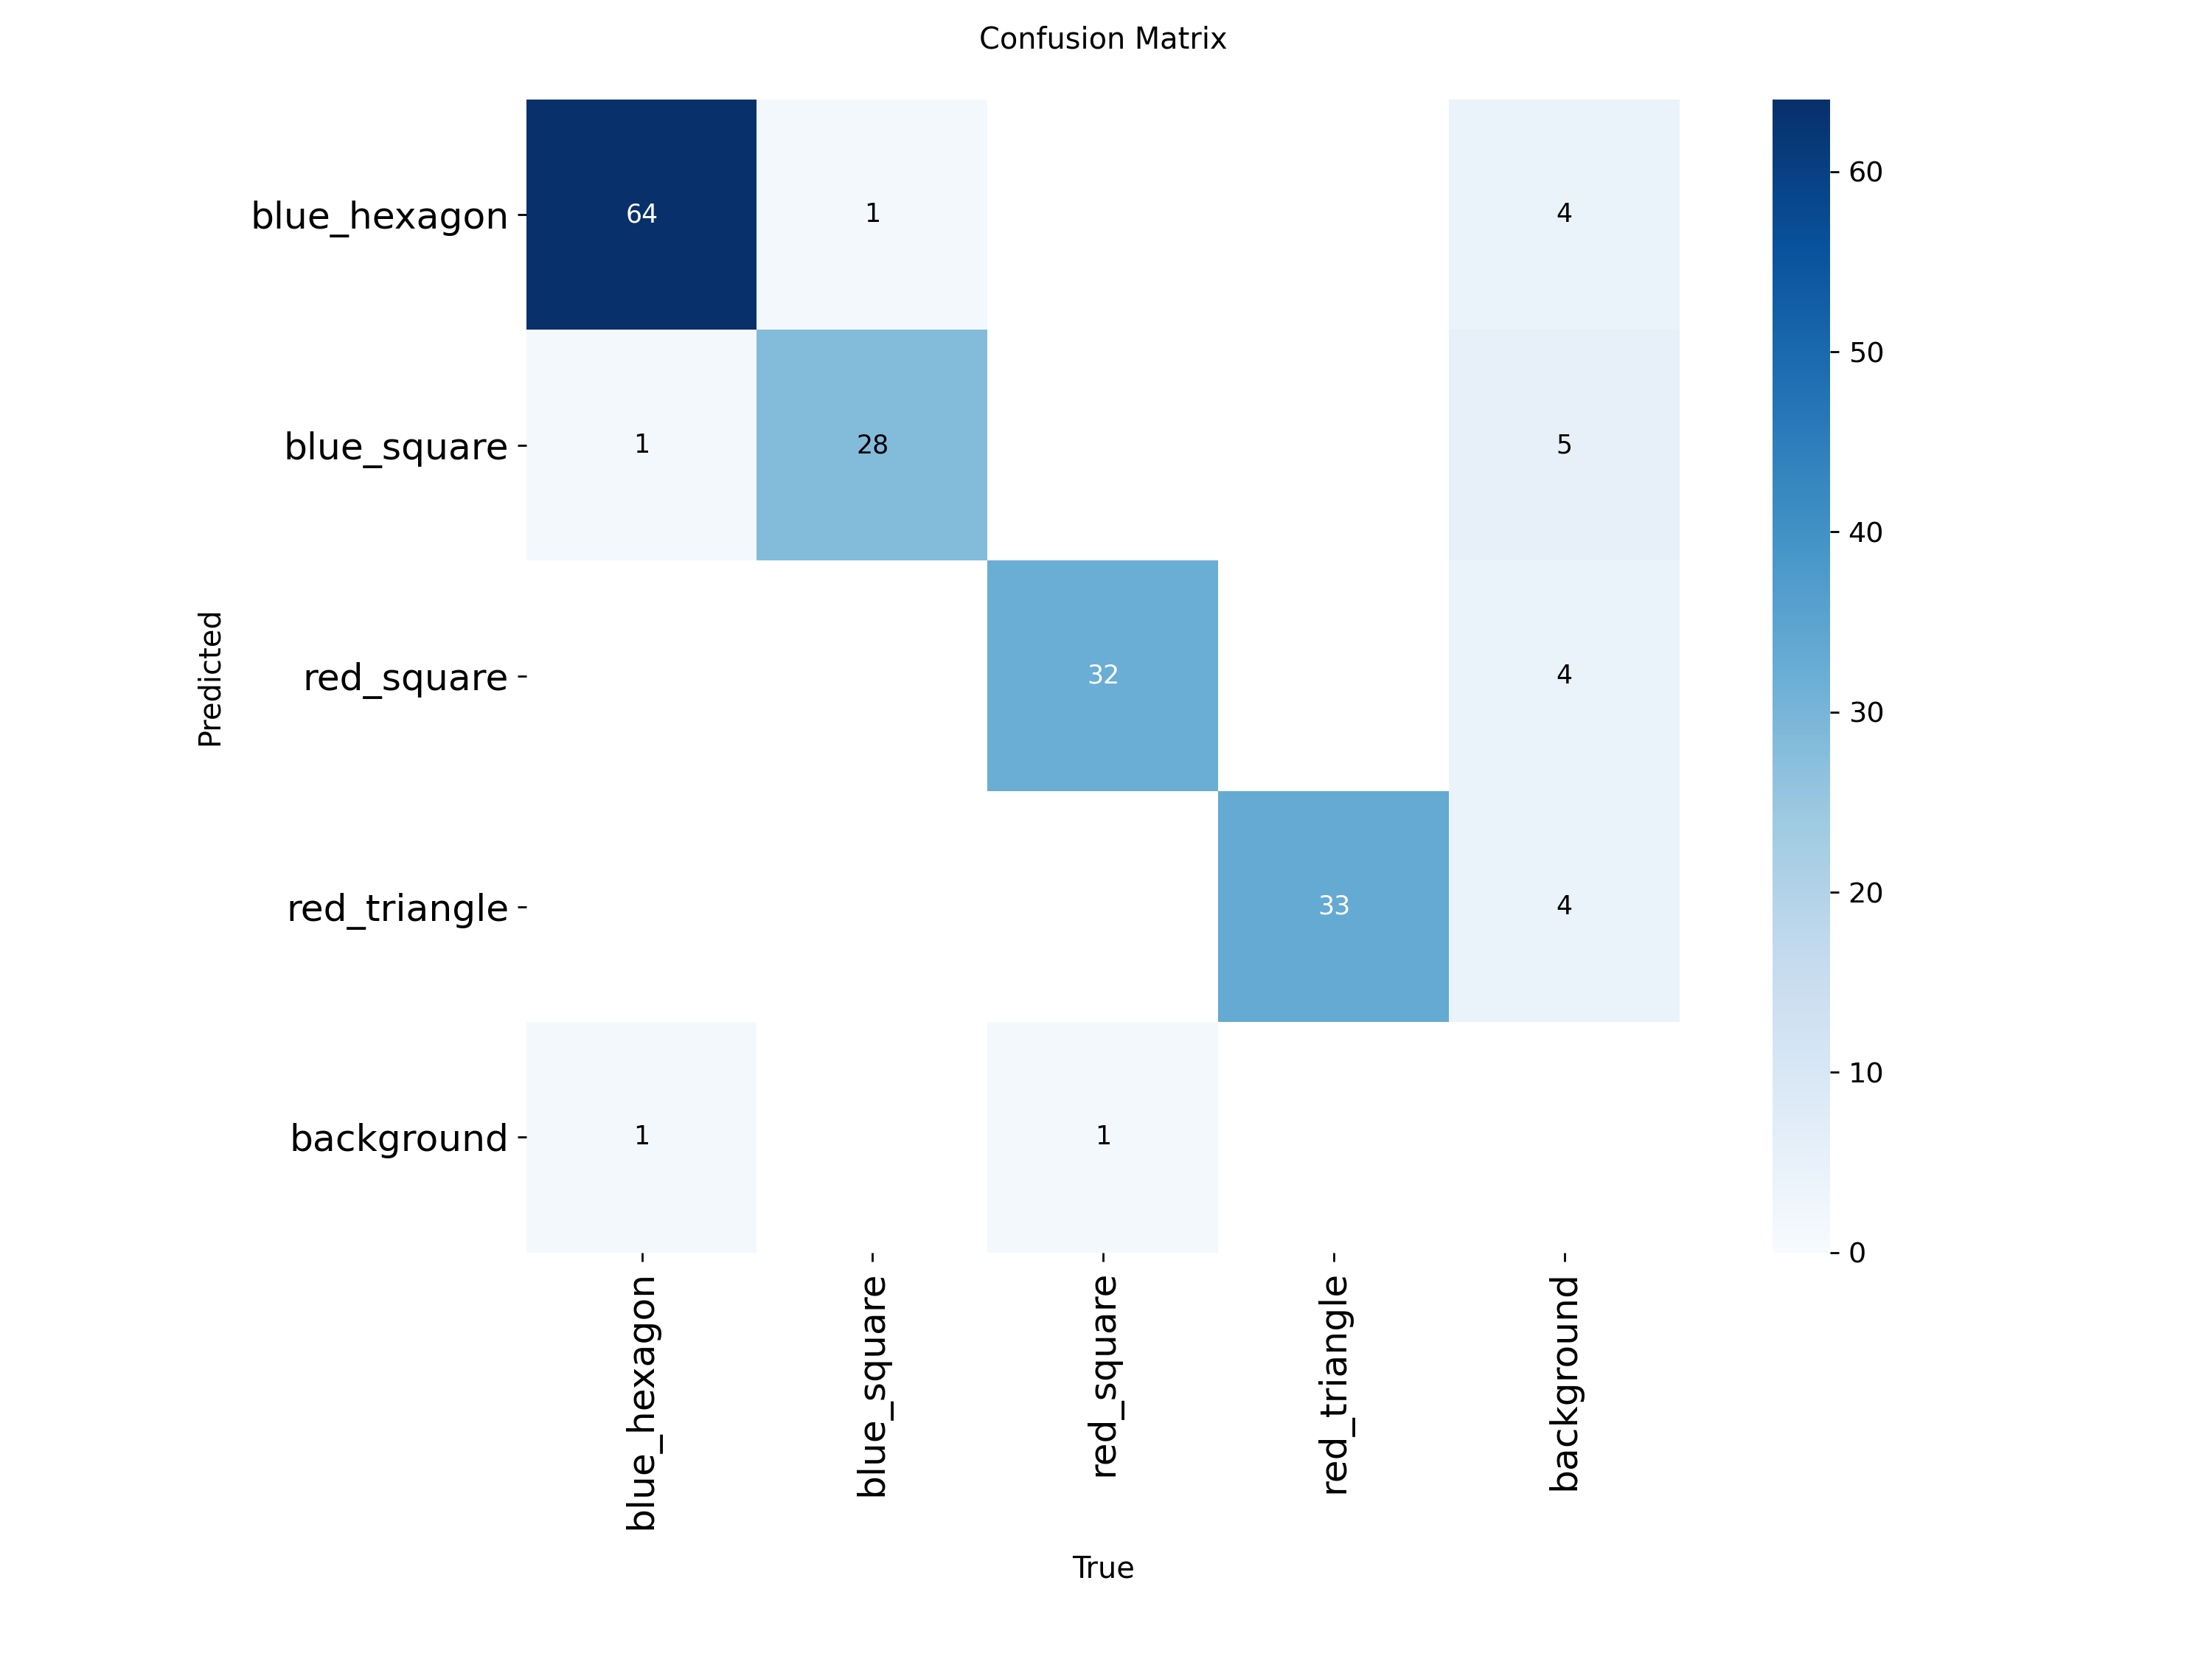


=== Eğitim Sonuç Grafikleri (Loss & mAP) ===


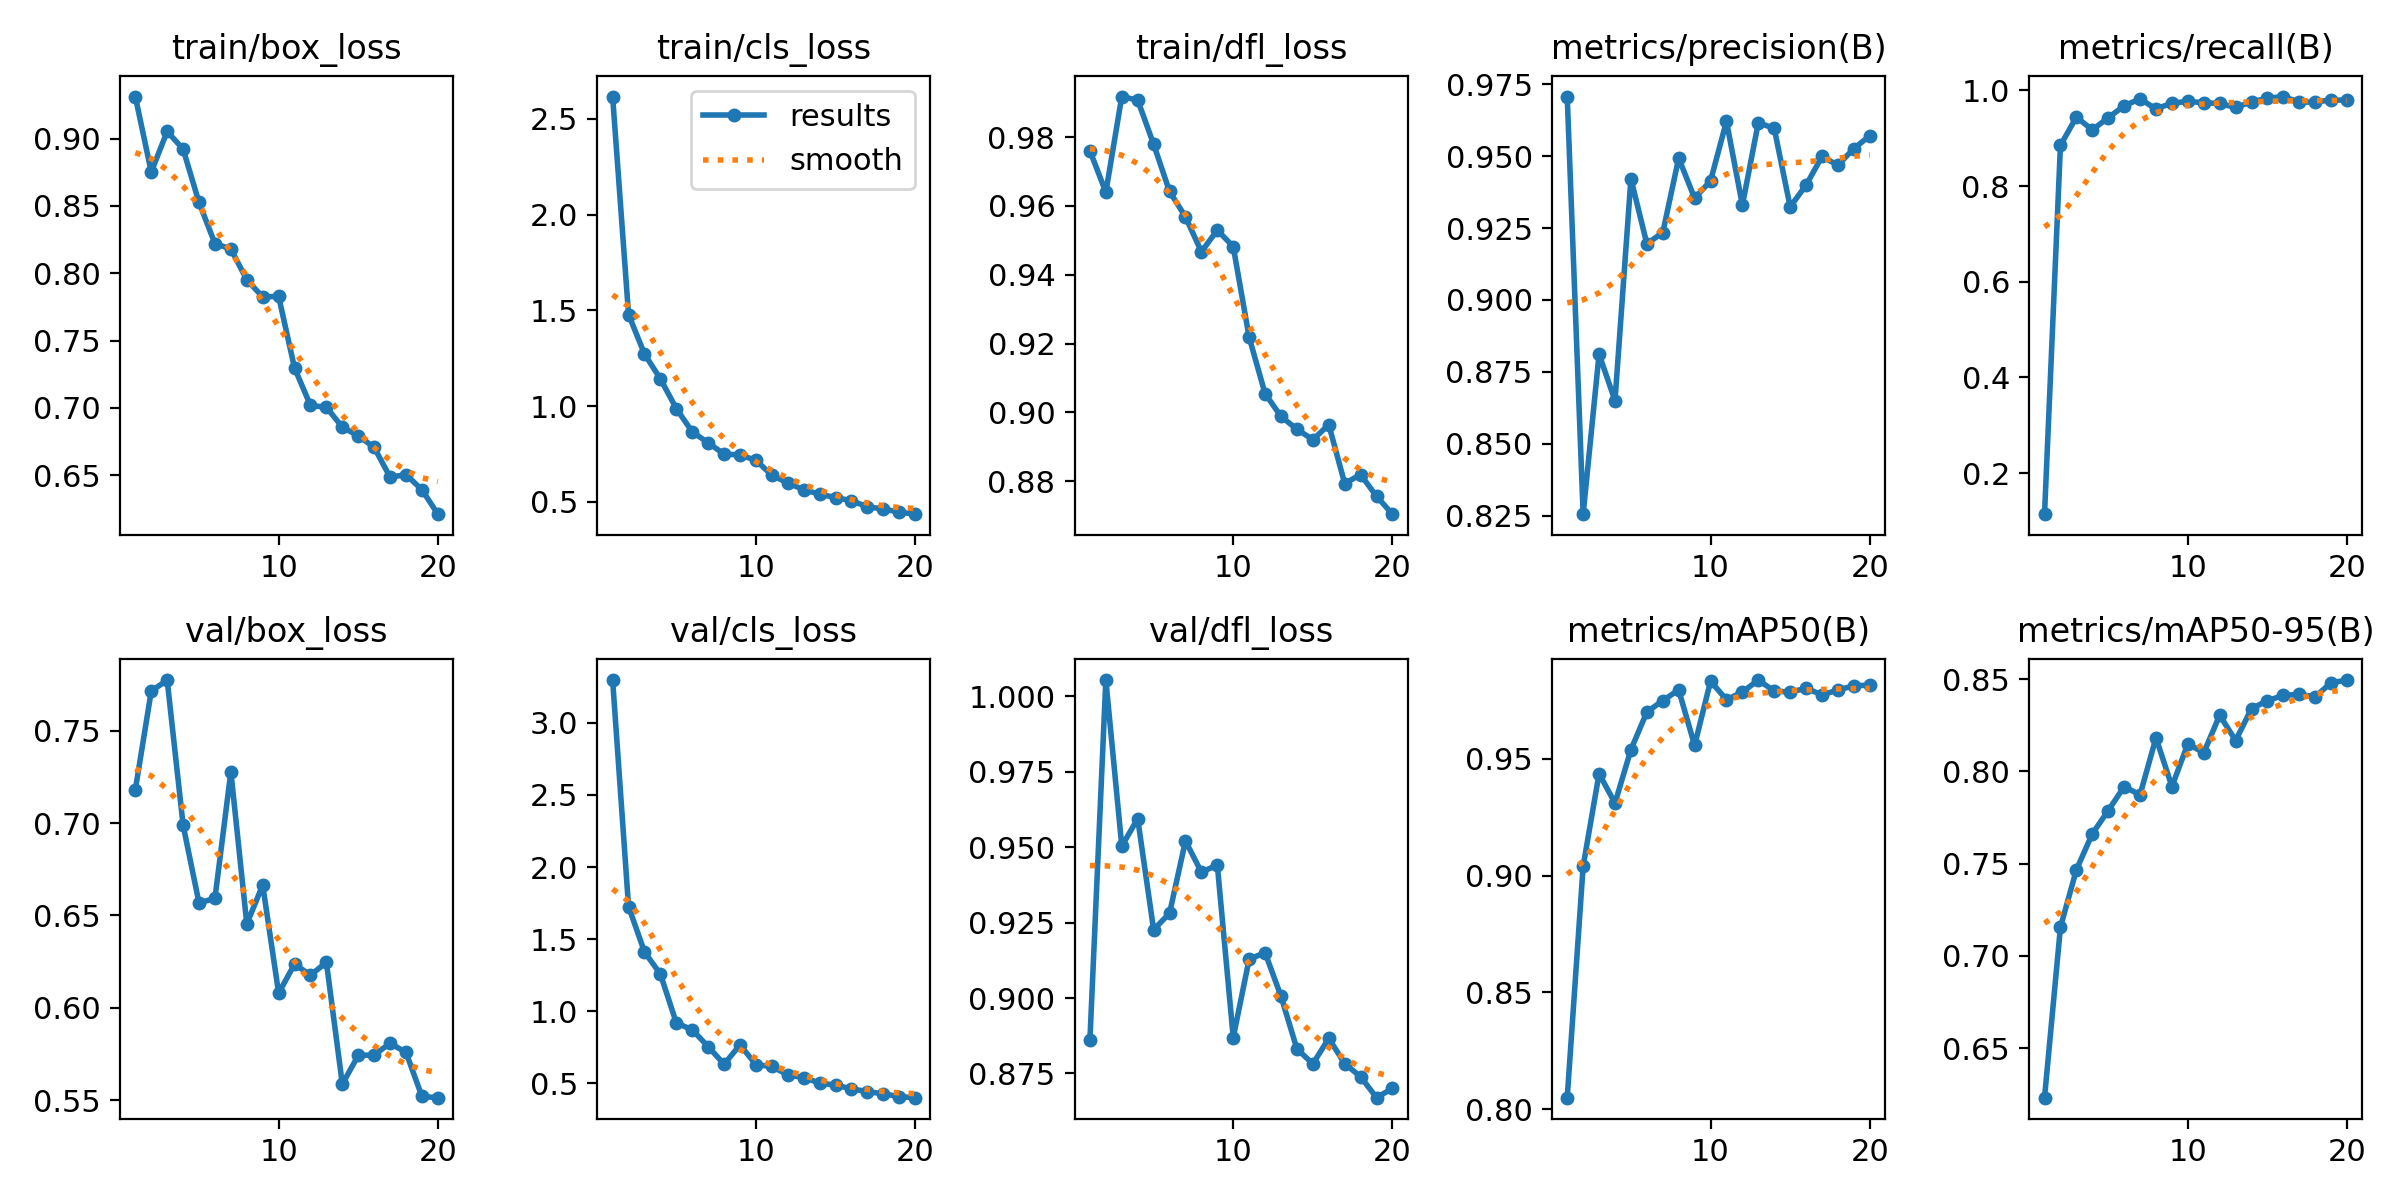


=== F1 Skoru Eğrisi ===


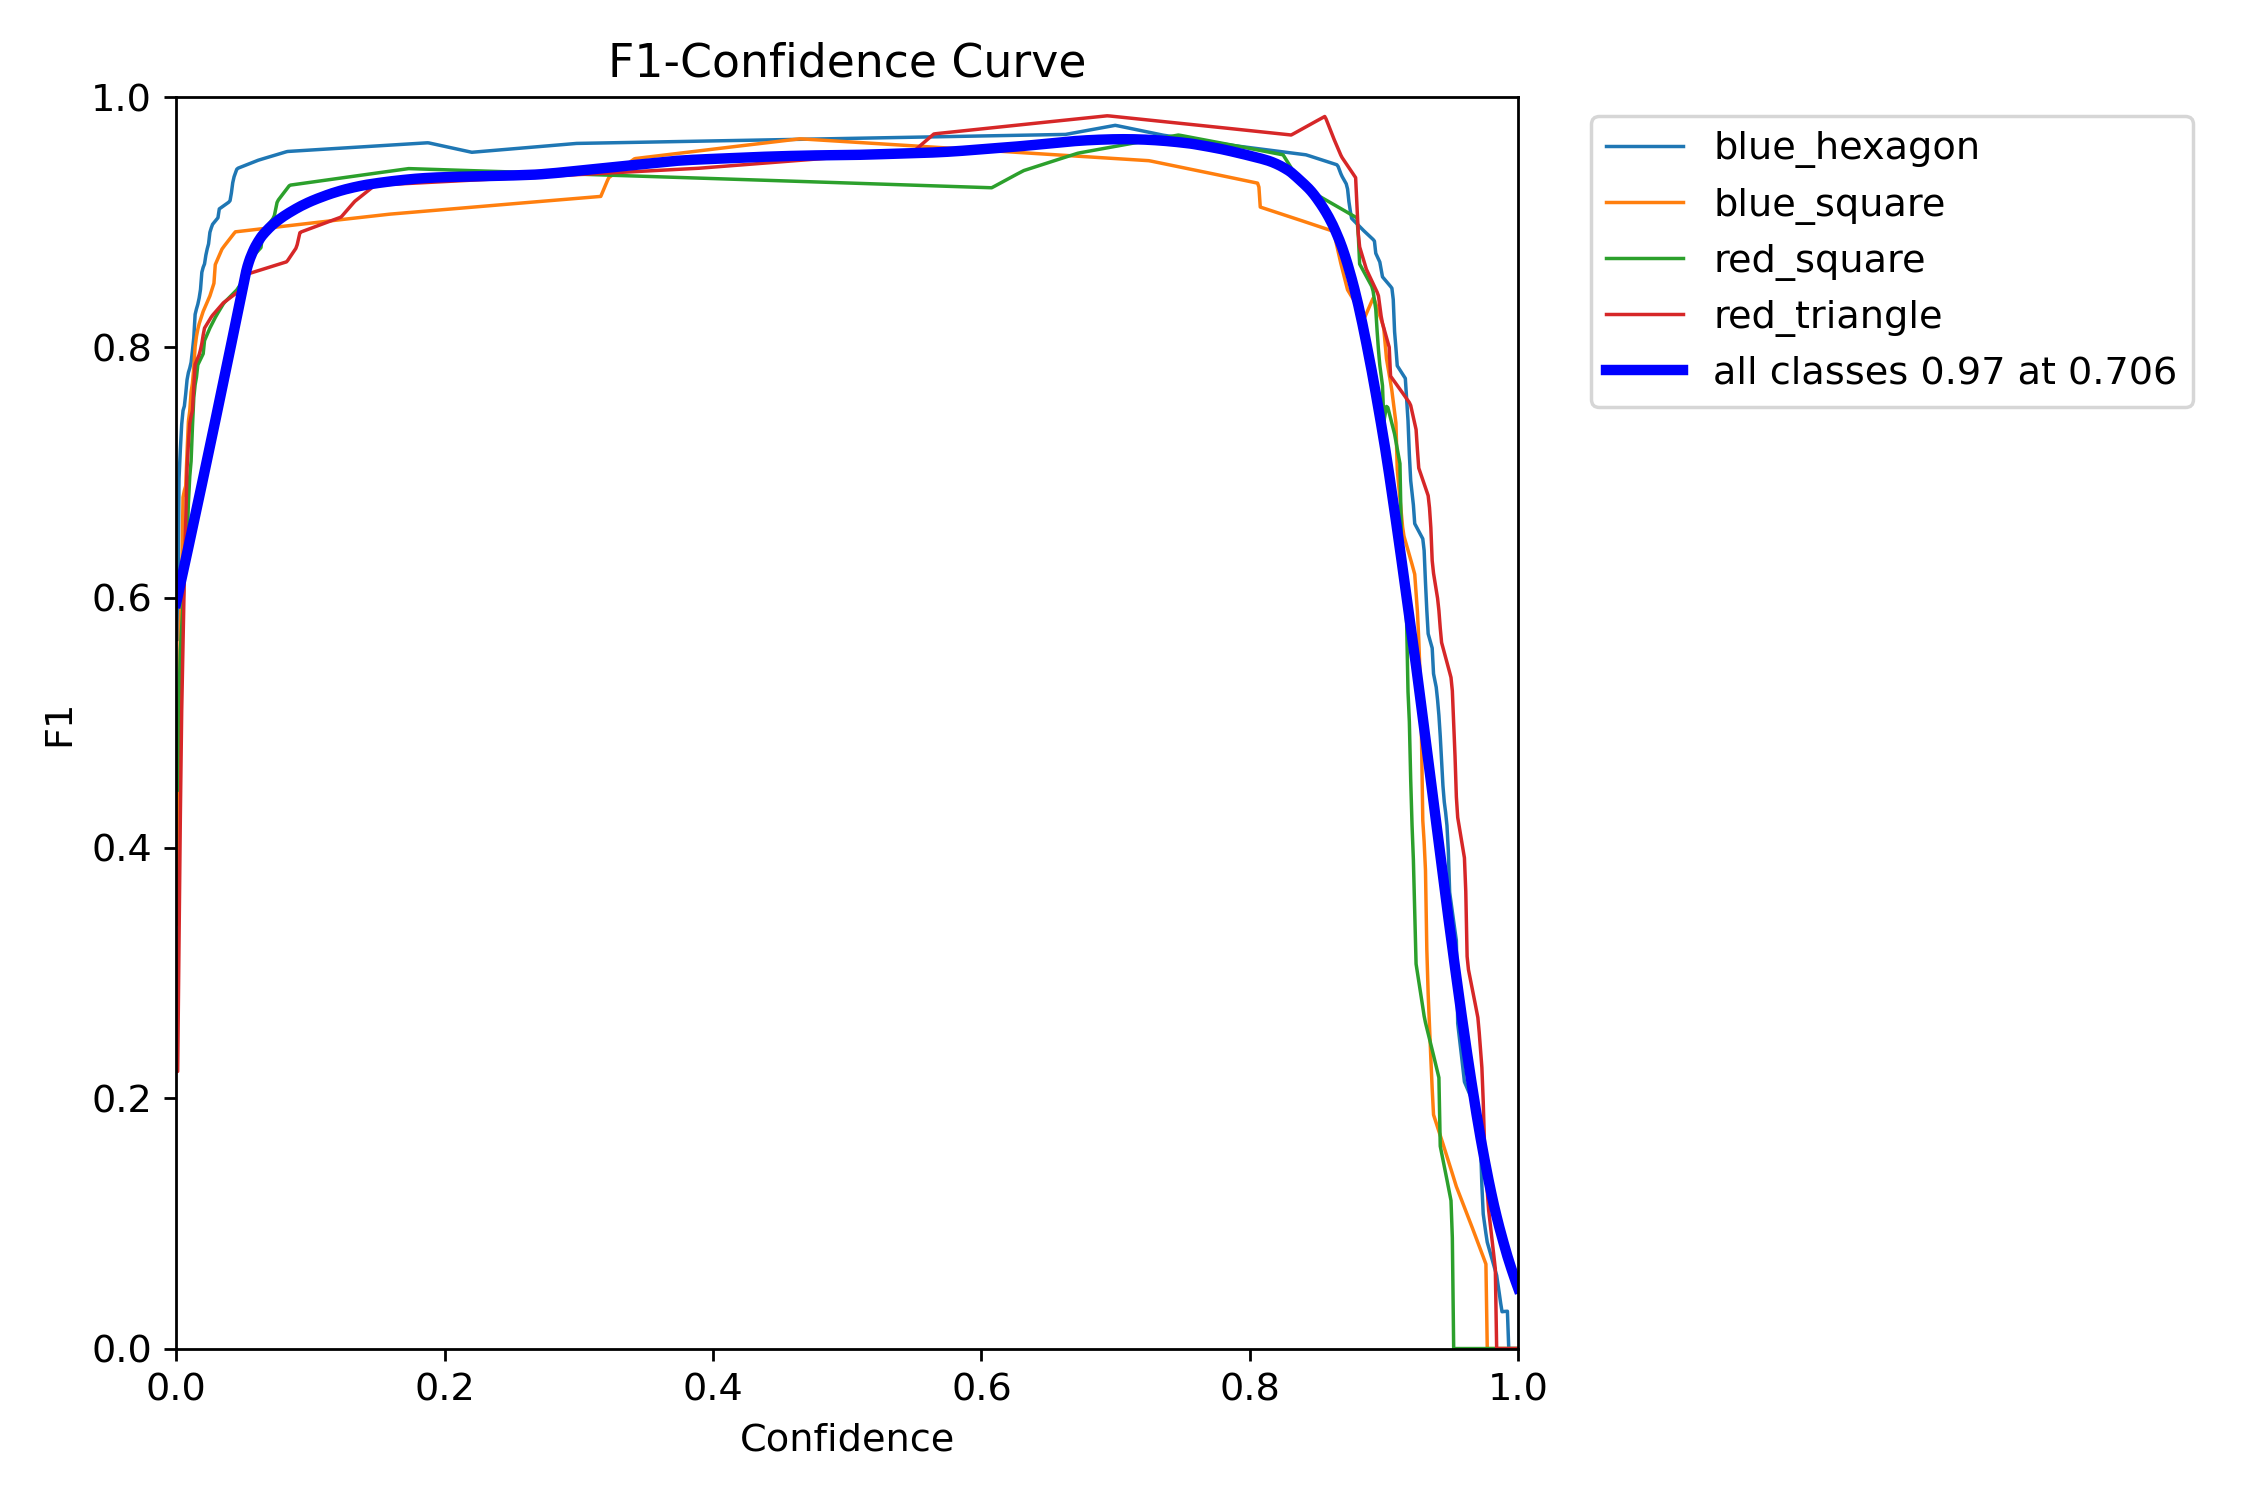

In [5]:
from IPython.display import Image, display
import os

# Modelin sonuçlarını kaydettiği klasör (Senin bilgisayarındaki son başarılı eğitim)
# NOT: Eğer klasör ismin farklıysa (yoda_modeli3 vb.) burayı güncellemeyi unutma.
results_folder = 'runs/detect/yoda_modeli2'
print("=== Karmaşıklık Matrisi (Confusion Matrix) ===")
# Modelin hangi sınıfı hangisiyle karıştırdığını gösterir.
# Köşegen üzerindeki koyu renkler başarının işaretidir.
display(Image(filename=os.path.join(results_folder, 'confusion_matrix.png'), width=600))

print("\n=== Eğitim Sonuç Grafikleri (Loss & mAP) ===")
# Box Loss: Kutuyu ne kadar doğru çizdiği (Düşük olmalı)
# mAP: Genel doğruluk puanı (Yüksek olmalı)
display(Image(filename=os.path.join(results_folder, 'results.png'), width=800))

print("\n=== F1 Skoru Eğrisi ===")
# Güven (Confidence) ve Doğruluk arasındaki dengeyi gösterir.
display(Image(filename=os.path.join(results_folder, 'BoxF1_curve.png'), width=600))


## Modelin Test Edilmesi ve Görselleştirme
Eğitilen modelin başarısını gözlemlemek için, modelin daha önce hiç görmediği **Test veri setinden** rastgele bir görüntü seçilmiştir.

Aşağıdaki görselleştirmede:
* **Sol Tarafta:** Modele girdi olarak verilen ham, orijinal drone görüntüsü,
* **Sağ Tarafta:** Modelin bu görüntü üzerinde tespit ettiği nesneleri (Bounding Box) ve güven skorlarını içeren sonuç görüntüsü yan yana sunulmuştur.

Görselleştirme başlatılıyor...
Seçilen Resim: 28_Temmuz_Ucus_2_3_frame_0396_jpg.rf.3474cca997cd14c6f34e1d1813e042f5.jpg
Çizim yapıldı, ekrana veriliyor...


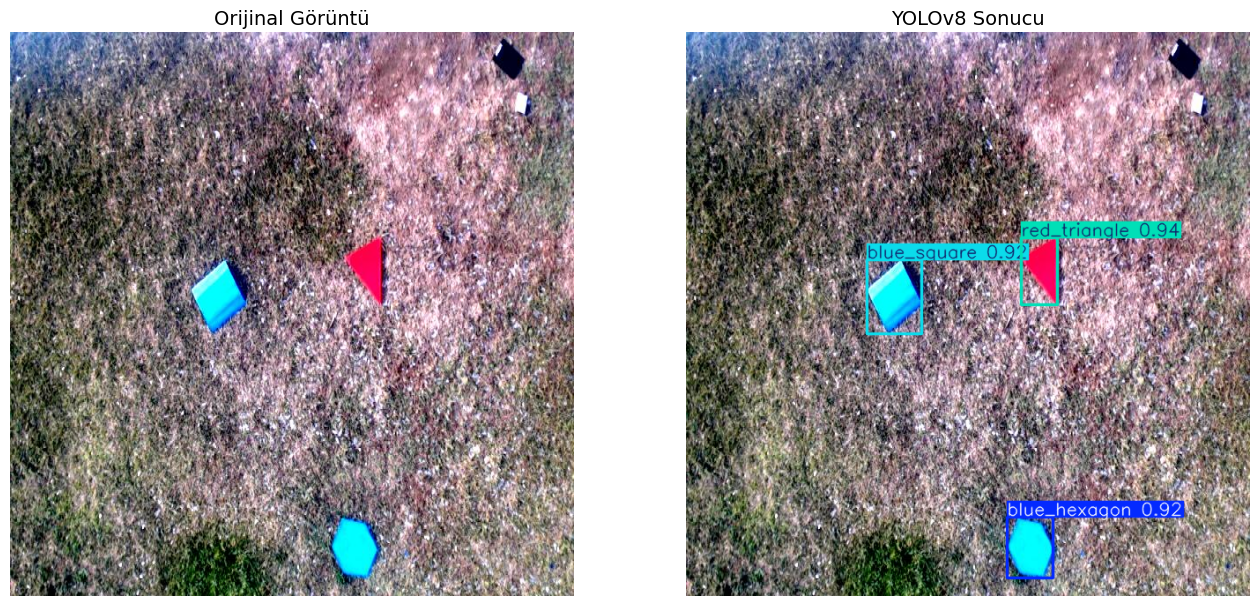

In [17]:
# BU SATIR ÇOK ÖNEMLİ: Grafiğin notebook içinde görünmesini sağlar
%matplotlib inline 

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random
import numpy as np

print("Görselleştirme başlatılıyor...")

# --- AYARLAR ---
test_folder = r'C:/Users/aydin/Desktop/Yazılım/Git/Aydin_Alizade_YODA_IHA_YAZILIM/Odev_5/yoda_odevlendirme_veriseti.yolov8/test/images'
model_path = 'runs/detect/yoda_modeli2/weights/best.pt'

# --- İŞLEM ---
model = YOLO(model_path)

# Rastgele resim seç
test_images = [img for img in os.listdir(test_folder) if img.endswith(('.jpg', '.png'))]
random_image_name = random.choice(test_images)
image_path = os.path.join(test_folder, random_image_name)

print(f"Seçilen Resim: {random_image_name}")

# Tahmin yap
results = model.predict(image_path, conf=0.5, verbose=False)

# Resimleri hazırla
img_orig_bgr = cv2.imread(image_path)
img_orig_rgb = cv2.cvtColor(img_orig_bgr, cv2.COLOR_BGR2RGB)

img_res_bgr = results[0].plot()
img_res_rgb = cv2.cvtColor(img_res_bgr, cv2.COLOR_BGR2RGB)

# --- ÇİZDİRME ---
# Figure oluştur (Boyutu biraz büyüttük)
plt.figure(figsize=(16, 8))

# Sol (Orijinal)
plt.subplot(1, 2, 1)
plt.imshow(img_orig_rgb)
plt.title("Orijinal Görüntü", fontsize=14)
plt.axis('off')

# Sağ (Tahmin)
plt.subplot(1, 2, 2)
plt.imshow(img_res_rgb)
plt.title("YOLOv8 Sonucu", fontsize=14)
plt.axis('off')

print("Çizim yapıldı, ekrana veriliyor...")
plt.show()